# Deep SARSA Snake – Training Notebook

This notebook trains a Deep SARSA agent on the Snake environment.

## Objectives
- Initialize the Snake environment and Deep SARSA agent  
- Configure hyperparameters such as replay buffer and target network usage  
- Train the agent for a defined number of episodes  
- Visualize training progress and performance trends

The notebook can be configured to train with or without a replay buffer or target network.

TRAIN_EPISODES = 25000
EPSILON_DECAY = 0.9998
LEARNING_RATE = 0.001


In [7]:
# Deep SARSA Snake - Training Notebook
# ====================================

import matplotlib.pyplot as plt
import importlib, dsarsa_snake
import torch
importlib.reload(dsarsa_snake)

from dsarsa_snake import (
    train_agent,
    SnakeGame,
    DeepSarsaAgent,
    MODEL_PATH
)


USE_REPLAY_BUFFER = False  # Set to True to use replay buffer
USE_TARGET = False         # Set to True to use target network
TRAIN_EPISODES = 25000     # Number of training episodes
GRID_SIZE = 10             # Size of the Snake game grid


# ------------------------------------------------------------
# 2️⃣ Initialize environment and agent
# ------------------------------------------------------------
env = SnakeGame(grid_size=GRID_SIZE)
agent = DeepSarsaAgent(
    use_target=USE_TARGET,
    replay_buffer=USE_REPLAY_BUFFER
)

## Train the Agent

The Deep SARSA agent is now trained in the Snake environment for the specified number of episodes.

During each episode:
- The agent interacts with the environment and updates its Q-values.
- The epsilon value gradually decays to shift from exploration to exploitation.
- The cumulative reward and score are recorded.

After training, performance metrics such as score, total reward, and epsilon progression will be visualized.


Training (Pure Deep SARSA) for 25000 episodes...
Episode 100/25000 | Score: 0 | Avg(100): 0.14 | Best: 2 | ε: 0.980
Episode 200/25000 | Score: 0 | Avg(100): 0.28 | Best: 2 | ε: 0.961
Episode 300/25000 | Score: 1 | Avg(100): 0.19 | Best: 2 | ε: 0.942
Episode 400/25000 | Score: 1 | Avg(100): 0.32 | Best: 2 | ε: 0.923
Episode 500/25000 | Score: 0 | Avg(100): 0.27 | Best: 2 | ε: 0.905
Episode 600/25000 | Score: 0 | Avg(100): 0.32 | Best: 2 | ε: 0.887
Episode 700/25000 | Score: 0 | Avg(100): 0.33 | Best: 2 | ε: 0.869
Episode 800/25000 | Score: 0 | Avg(100): 0.32 | Best: 2 | ε: 0.852
Episode 900/25000 | Score: 0 | Avg(100): 0.38 | Best: 3 | ε: 0.835
Episode 1000/25000 | Score: 0 | Avg(100): 0.38 | Best: 3 | ε: 0.819
Episode 1100/25000 | Score: 0 | Avg(100): 0.48 | Best: 3 | ε: 0.803
Episode 1200/25000 | Score: 1 | Avg(100): 0.51 | Best: 3 | ε: 0.787
Episode 1300/25000 | Score: 0 | Avg(100): 0.55 | Best: 3 | ε: 0.771
Episode 1400/25000 | Score: 1 | Avg(100): 0.56 | Best: 3 | ε: 0.756
Episode 

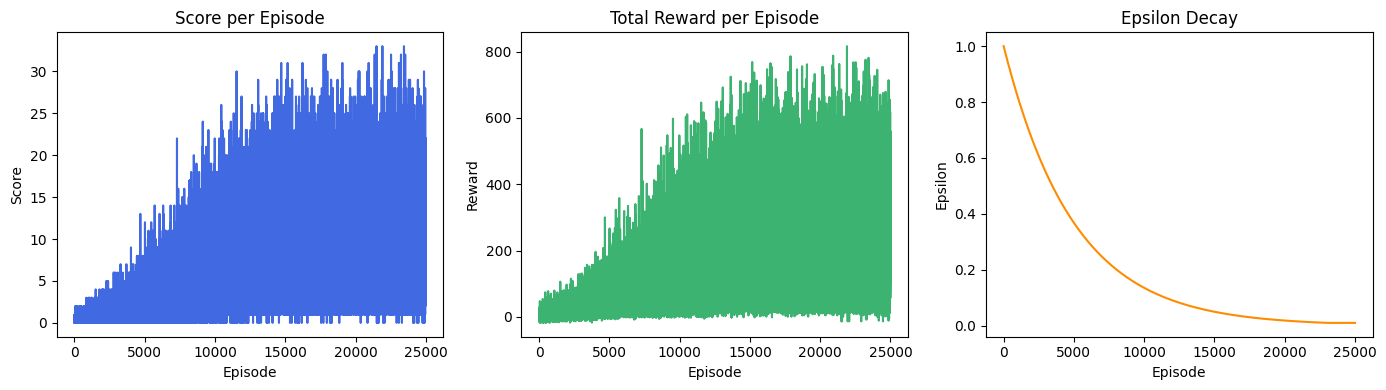


Training completed in mode: Pure Deep SARSA (On-Policy)
✓ Model saved to improved_D_SARSA_snake_10x10.pth
✓ Full model saved to D_SARSA_snake_full_model.pth
✓ Model exported to D_SARSA_snake.onnx for Netron visualization
------------------------------------------------------------


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_29352\4224526134.py:55: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(agent.model, dummy_input, "./neutron/D_SARSA_snake.onnx",


In [8]:
# ------------------------------------------------------------
# 3️⃣ Train agent
# ------------------------------------------------------------
scores, rewards, epsilons = train_agent(env, agent, episodes=TRAIN_EPISODES)

# ------------------------------------------------------------
# 4️⃣ Visualize performance metrics
# ------------------------------------------------------------
plt.figure(figsize=(14, 4))

# --- Score per Episode ---
plt.subplot(1, 3, 1)
plt.plot(scores, color='royalblue')
plt.title('Score per Episode')
plt.xlabel('Episode')
plt.ylabel('Score')

# --- Total Reward per Episode ---
plt.subplot(1, 3, 2)
plt.plot(rewards, color='mediumseagreen')
plt.title('Total Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Reward')

# --- Epsilon Decay ---
plt.subplot(1, 3, 3)
plt.plot(epsilons, color='darkorange')
plt.title('Epsilon Decay')
plt.xlabel('Episode')
plt.ylabel('Epsilon')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5️⃣ Summary of mode used
# ------------------------------------------------------------
if USE_TARGET and USE_REPLAY_BUFFER:
    mode_name = "Deep SARSA with Replay Buffer + Target Network"
elif USE_TARGET:
    mode_name = "Deep SARSA with Target Network"
elif USE_REPLAY_BUFFER:
    mode_name = "Deep SARSA with Replay Buffer"
else:
    mode_name = "Pure Deep SARSA (On-Policy)"

print(f"\nTraining completed in mode: {mode_name}")
torch.save(agent.model.state_dict(), MODEL_PATH)
torch.save(agent.model, "./neutron/D_SARSA_snake_full_model.pth")
print(f"✓ Model saved to {MODEL_PATH}")
print("✓ Full model saved to D_SARSA_snake_full_model.pth")

# Export ONNX model (same IO: state -> Q_values for all actions)
dummy_input = torch.randn(1, 16)
torch.onnx.export(agent.model, dummy_input, "./neutron/D_SARSA_snake.onnx",
                    input_names=["state"], output_names=["Q_values"],
                    opset_version=12)
print("✓ Model exported to D_SARSA_snake.onnx for Netron visualization")

print("------------------------------------------------------------")